In [30]:
!pip install wordcloud


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import ast
from collections import Counter

df = pd.read_csv("/content/tweets_with_sentiement_FIN.csv", low_memory=False)

df.head()


,Full Language name,SLC time,Tweet created during quarter,assigned_brand,attachments.media_keys,attachments.media_source_tweet_id,attachments.poll_ids,author_id,brand,text,...,referenced_tweets,reply_settings,suggested_brand,Unnamed: 43,urls,username,withheld.country_codes,tweet_id,sentiment,confidence
0,English,2/8/2026 16:33,Quarter 1,0,NaN,NaN,NaN,3.789265e+08,Boehringer Ingelheim_1,@SofiaVergara is a national treasure,...,NaN,everyone,0,NaN,0,djchrisg585,NaN,2.020640e+18,positive,0.990607
1,English,2/8/2026 16:33,Quarter 1,0,['13_2020642142658428928'],NaN,NaN,3.020559e+07,Boehringer Ingelheim_1,.@boehringerus is airing a #SuperBowl spot fea...,...,NaN,everyone,0,NaN,https://t.co/HIPcOizIqh,Adweek,NaN,2.020640e+18,neutral,0.859994
2,English,2/8/2026 16:34,Quarter 1,0,['3_2020642322783068160'],NaN,NaN,1.356090e+18,Rippling_1,#rippling so much fun at your event! https://t...,...,NaN,everyone,0,NaN,https://t.co/ZBRlmRhKUg,Dobits3,NaN,2.020640e+18,positive,0.992488
3,English,2/8/2026 16:36,Quarter 1,0,NaN,NaN,NaN,1.939280e+18,Kellogg’s_1,@MrJOHNWICK2 LIST OF STOCK THAT I’M SHORTING\r...,...,"[{'type': 'replied_to', 'id': '202037707959503...",everyone,0,NaN,0,TopCatTrader,NaN,2.020640e+18,neutral,0.732880
4,Japanese,2/8/2026 16:37,Quarter 1,0,['3_2020050337235873792'],2.02024E+18,NaN,2.549707e+09,Rippling_1,RT @Takashi_LF: 🗻\r\n波立つ湖畔から、ダイヤモンド富士\r\n\r\nD...,...,"[{'type': 'retweeted', 'id': '2020241158853603...",everyone,0,NaN,https://t.co/FXhJL1Q02O,isok55,NaN,2.020640e+18,neutral,0.968235


Languages

In [32]:
lang_counts = df["Full Language name"].value_counts()

# Remove rare noise languages
lang_counts = lang_counts[lang_counts >= 5]

lang_counts


,count
Full Language name,
English,38222
Portuguese,3332
Spanish,3262
Japanese,1262
Mixed European languages (platform-specific),1153
Undefined / Unknown language,607
Tagalog / Filipino,412
Indonesian,376
Thai,242


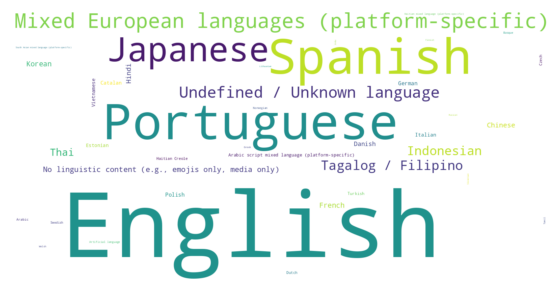

In [33]:
wc_lang = WordCloud(
    width=1600,
    height=800,
    background_color="white"
).generate_from_frequencies(lang_counts.to_dict())

plt.figure(figsize=(7,3))
plt.imshow(wc_lang, interpolation="bilinear")
plt.axis("off")
# plt.title("", fontsize=16)
plt.tight_layout()
plt.show()


Hashtags

Parent companies: 28
Top companies: [('pepsico', 1059), ('anheuser-busch', 581), ('apple', 105), ('openai', 73), ('verizon', 73), ('qualcomm', 73), ('alphabet', 22), ('volkswagen_group', 19), ('novo_nordisk', 10), ('tmobile', 9)]


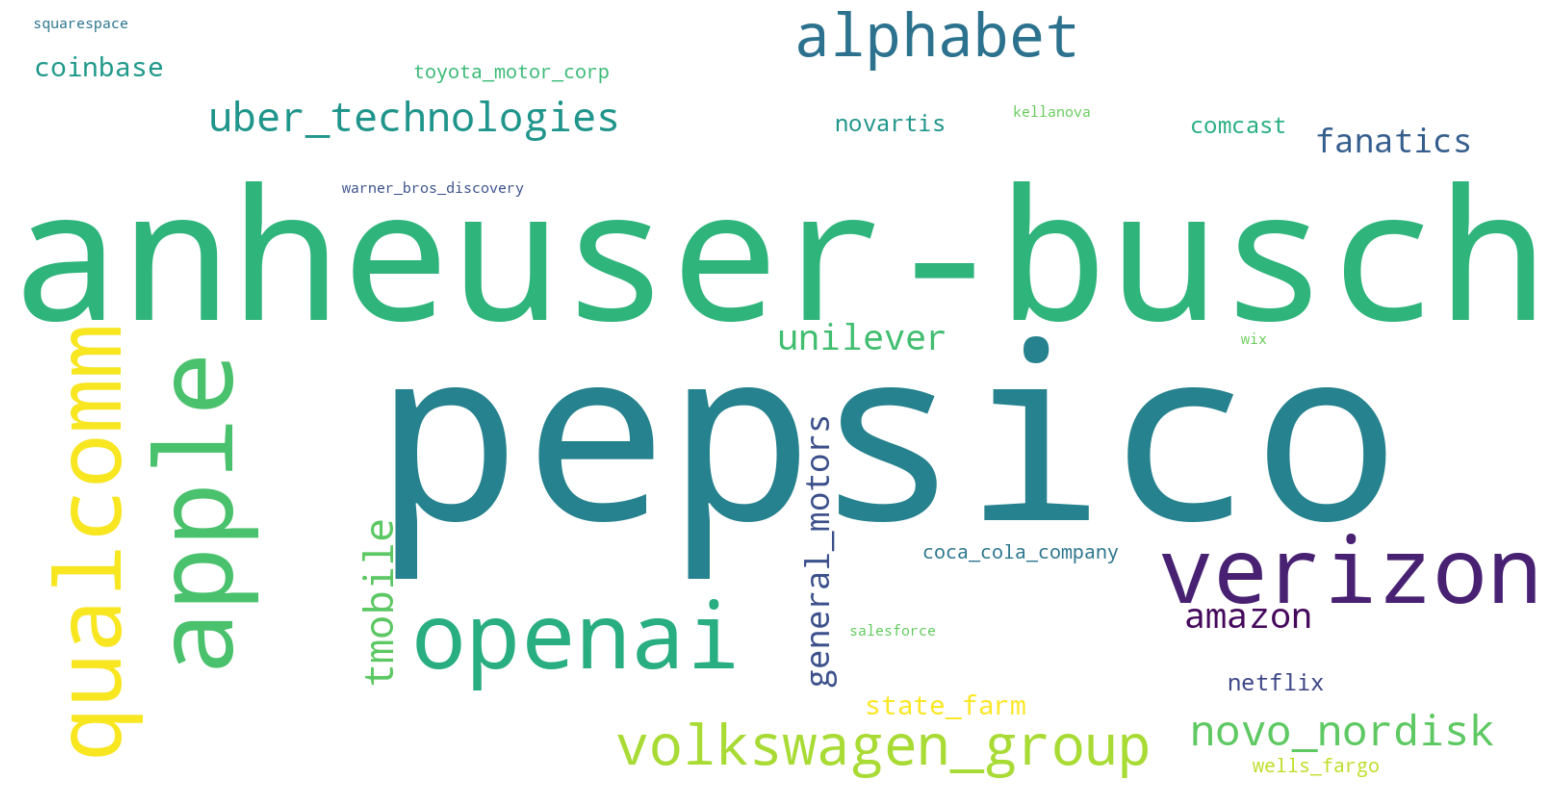

In [49]:
import json
from wordcloud import WordCloud
import matplotlib.pyplot as plt

PATH = "/content/parent_company_groups_2026.json"

with open(PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

freq = {}

for pc in data["parent_companies"]:
    parent = str(pc["parent_company"]).strip().lower()
    count = int(pc.get("total_count", 0))

    if parent and count > 0:
        freq[parent] = count

print("Parent companies:", len(freq))
print("Top companies:", sorted(freq.items(), key=lambda x: x[1], reverse=True)[:10])


wc = WordCloud(
    width=1600,
    height=800,
    background_color="white"
).generate_from_frequencies(freq)

plt.figure(figsize=(16,8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")

plt.tight_layout()
plt.show()



Unique parent companies: 629
Top 15: [('pepsico', 1059), ('sweepstakes', 623), ('michelob ultra', 506), ('formula1', 124), ('apple', 105), ('blackpink', 76), ('ab-inbev', 75), ('bosch', 75), ('accenture', 73), ('mwc2026', 73), ('mwc26', 73), ('openai', 73), ('qualcomm', 73), ('verizon', 73), ('eatthefees', 59)]


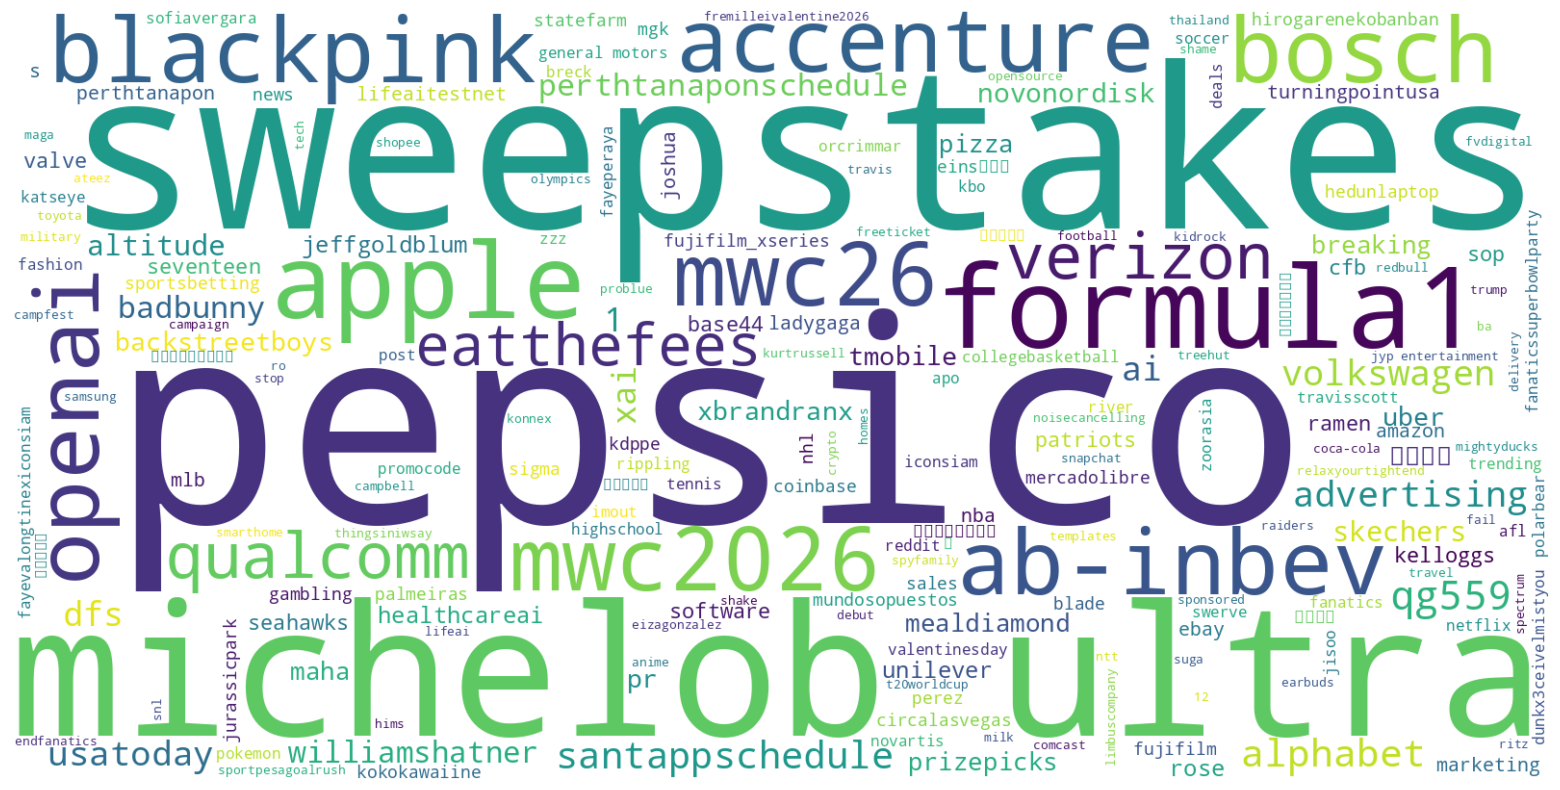

In [52]:
import json
from wordcloud import WordCloud
import matplotlib.pyplot as plt

PATH = "/content/parent_company_groups.json"

with open(PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

freq = {}
for pc in data["parent_companies"]:
    name = str(pc["parent_company"]).strip().lower()
    cnt = int(pc.get("total_count", 0))
    if name and cnt > 0:
        freq[name] = freq.get(name, 0) + cnt

# stop_companies = {
#    "superbowl", "nfl", "halftimeshow", "commercial", "ads", "ad"
#}
freq = {k:v for k,v in freq.items() if k not in stop_companies}

print("Unique parent companies:", len(freq))
print("Top 15:", sorted(freq.items(), key=lambda x: x[1], reverse=True)[:15])

wc = WordCloud(width=1600, height=800, background_color="white").generate_from_frequencies(freq)

plt.figure(figsize=(16,8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
# plt.title("Brand Buzz by Parent Company (Combined)", fontsize=16)
plt.tight_layout()
plt.show()

wc.to_file("/content/wordcloud_parent_companies.png")


Top tags preview: ['entry', 'cadillacf1team', 'santappschedule', 'mwc26', 'roséatsuperbowl', 'cadillacf1', 'superbowllx', 'chatgpt', 'gemini', 'qualcomm']
Parent companies represented: 24
Top 15 parents (filtered): [('pepsico', 1043), ('superbowl', 646), ('sweepstakes', 623), ('michelob ultra', 503), ('apple', 104), ('nfl', 83), ('formula1', 76), ('bosch', 73), ('accenture', 73), ('mwc2026', 73), ('mwc26', 73), ('qualcomm', 73), ('verizon', 73), ('ab-inbev', 72), ('blackpink', 70)]


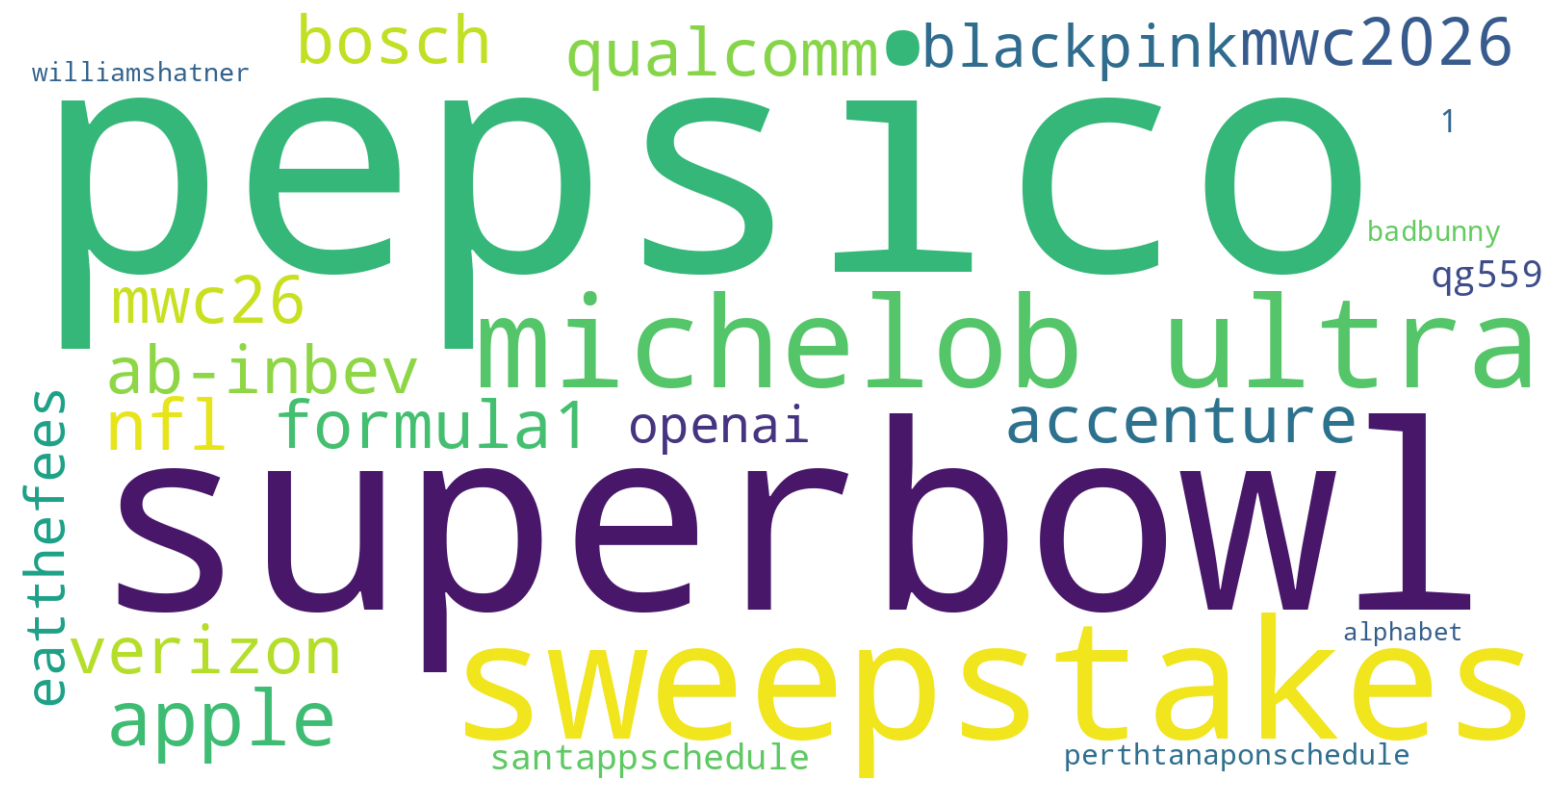

In [51]:
import json
from collections import Counter, defaultdict
from wordcloud import WordCloud
import matplotlib.pyplot as plt

PATH = "/content/parent_company_groups.json"
TOP_N_HASHTAGS = 40  # <-- adjustable

with open(PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

global_tag_counts = Counter()
tag_to_parent_counts = defaultdict(Counter)
for pc in data["parent_companies"]:
    parent = str(pc["parent_company"]).strip().lower()
    for brand in pc.get("brands", []):
        for t in brand.get("hashtags", []):
            tag = str(t.get("hashtag", "")).strip().lower()
            cnt = int(t.get("count", 0))
            if tag and cnt > 0:
                global_tag_counts[tag] += cnt
                tag_to_parent_counts[parent][tag] += cnt

top_tags = set([t for t, _ in global_tag_counts.most_common(TOP_N_HASHTAGS)])

print("Top tags preview:", list(top_tags)[:10])

parent_freq = {}
for parent, counter in tag_to_parent_counts.items():
    s = sum(cnt for tag, cnt in counter.items() if tag in top_tags)
    if s > 0:
        parent_freq[parent] = s

print("Parent companies represented:", len(parent_freq))
print("Top 15 parents (filtered):", sorted(parent_freq.items(), key=lambda x: x[1], reverse=True)[:15])


wc = WordCloud(width=1600, height=800, background_color="white") \
    .generate_from_frequencies(parent_freq)

plt.figure(figsize=(16,8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
#plt.title(f")", fontsize=16)
plt.tight_layout()
plt.show()

wc.to_file("/content/wordcloud_parent_companies_top_hashtags.png")
